### Necessary Libraries

In [2]:
import pandas as np
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame = True)

df = housing.frame

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### EDA - Exploratory Data Analysis

In [5]:
print(df.shape)
print(df.describe())
print(df.info())
print(df.isna().sum())

(20640, 9)
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308  

[]

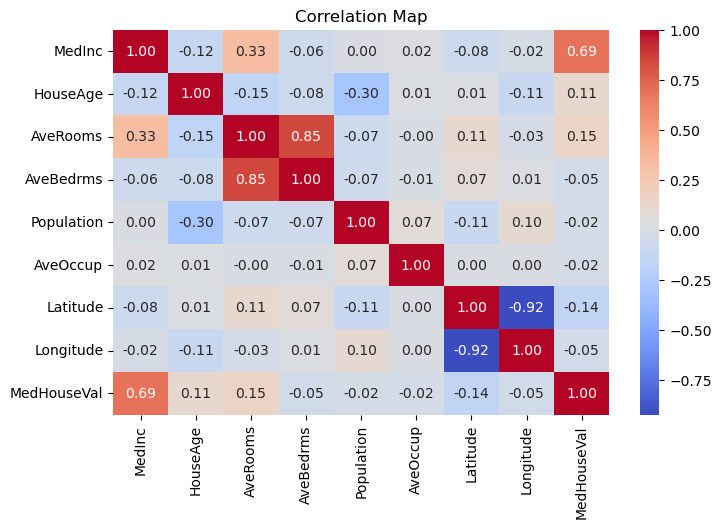

In [7]:
corr_matrix = df.corr(numeric_only = True)

plt.figure(figsize = (8, 5))

sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = 'coolwarm')

plt.title("Correlation Map")
plt.plot()

### Model Training and Testing

In [9]:
X = df.drop(columns = 'MedHouseVal')
Y = df['MedHouseVal']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)

model = LinearRegression()

model.fit(x_train, y_train)

print(model.intercept_)
print(model.coef_)

-37.13340393676631
[ 4.36589487e-01  9.68676548e-03 -1.08559303e-01  6.52863426e-01
 -3.16035634e-06 -3.53250327e-03 -4.23024323e-01 -4.36545767e-01]


In [10]:
y_pred = model.predict(x_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(r2)

0.5237282637132301
0.5237282637132301
0.6194946395677327


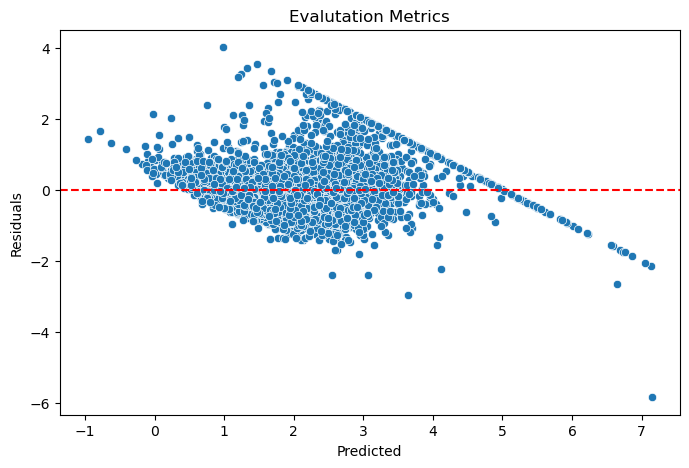

In [13]:
residuals = y_test - y_pred

plt.figure(figsize = (8, 5))

sns.scatterplot(x = y_pred, y = residuals)

plt.axhline(0, color = 'red', linestyle = '--')
plt.title("Evalutation Metrics")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()